# SE2_data_processing


### Dataset 1: Station ecological information

- Source: Provided dataset (station_with_ecology_values.csv)
- Description: Contains monitoring station identifiers and ecological status classification.
- Variables:
  - Site_Id: Unique station identifier
  - LakeCode: Unique lake identifier
  - ekoltasoid: Ecological status class (categorical)

---

### Dataset 2: Total Nitrogen (TN)

- Source: Monitoring dataset (tn323.csv)
- Description: Contains total nitrogen measurements at different times and depths.
- Key variables:
  - Site_Id: Station identifier
  - Time: Sampling timestamp
  - SampleDepth_m: Sampling depth
  - Value: TN concentration (µg/L)
- Temporal coverage: Multiple years (filtered to 2012–2017)
- Data format: CSV

---

### Dataset 3: Total Phosphorus (TP)

- Source: Monitoring dataset (tp315.csv)
- Description: Contains total phosphorus measurements.
- Variables similar to TN dataset.
- Unit: µg/L

---

### Dataset 4: Turbidity

- Source: Monitoring dataset (turbidity7677.csv)
- Description: Contains turbidity measurements.
- Variables similar to TN dataset.
- Unit: NTU (assumed)

---

### Notes

All datasets are tabular and linked using Site_Id. No spatial coordinate system (CRS) is required at this stage.

1. DATA INGESTION

In [18]:
import pandas as pd
from pathlib import Path

project_dir = Path.cwd()
raw_data_dir = project_dir.parent / "waterdigil"
analysis_ready_dir = project_dir.parent / "analysis_ready"
analysis_ready_dir.mkdir(exist_ok=True)

# Load datasets
tn = pd.read_csv(raw_data_dir / "tn323.csv")
tp = pd.read_csv(raw_data_dir / "tp315.csv")
turb = pd.read_csv(raw_data_dir / "turbidity7677.csv")
stations = pd.read_csv(raw_data_dir / "station_with_ecology_values.csv")


C:\Users\mehramah\AppData\Local\Temp\ipykernel_35700\2987655635.py:10: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  tn = pd.read_csv(raw_data_dir / "tn323.csv")


2. QUALITY CONTROL
   
Time was restricted to 2012–2017 to match the study period.

Surface layer (0–2 m) was selected because it best represents ecological conditions.

Outliers were removed:

TN > 1300 µg/L

TP > 100 µg/L

Turbidity > 40 NTU


In [19]:
# Convert time column
for df in [tn, tp, turb]:
    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

# Filter time (2012–2017)
tn = tn[(tn["Time"].dt.year >= 2012) & (tn["Time"].dt.year <= 2017)]
tp = tp[(tp["Time"].dt.year >= 2012) & (tp["Time"].dt.year <= 2017)]
turb = turb[(turb["Time"].dt.year >= 2012) & (turb["Time"].dt.year <= 2017)]

# Convert depth to numeric (handle weird format like "0.0 - 2.0")
def clean_depth(df):
    df["SampleDepth_m"] = df["SampleDepth_m"].astype(str).str.split("-").str[0]
    df["SampleDepth_m"] = pd.to_numeric(df["SampleDepth_m"], errors="coerce")
    return df

tn = clean_depth(tn)
tp = clean_depth(tp)
turb = clean_depth(turb)

# Filter depth (0–2 m)
tn = tn[(tn["SampleDepth_m"] >= 0) & (tn["SampleDepth_m"] <= 2)]
tp = tp[(tp["SampleDepth_m"] >= 0) & (tp["SampleDepth_m"] <= 2)]
turb = turb[(turb["SampleDepth_m"] >= 0) & (turb["SampleDepth_m"] <= 2)]

# Remove outliers
tn = tn[tn["Value"] <= 1300]
tp = tp[tp["Value"] <= 100]
turb = turb[turb["Value"] <= 40]

C:\Users\mehramah\AppData\Local\Temp\ipykernel_35700\3950036824.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SampleDepth_m"] = df["SampleDepth_m"].astype(str).str.split("-").str[0]
C:\Users\mehramah\AppData\Local\Temp\ipykernel_35700\3950036824.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SampleDepth_m"] = pd.to_numeric(df["SampleDepth_m"], errors="coerce")


3. Harmonization
   
Variables were standardized to site-level observations.

Only relevant columns (Site_Id, Value) were retained.

In [20]:
# Keep only relevant columns
tn = tn[["Site_Id", "Value"]].rename(columns={"Value": "TN"})
tp = tp[["Site_Id", "Value"]].rename(columns={"Value": "TP"})
turb = turb[["Site_Id", "Value"]].rename(columns={"Value": "Turbidity"})

4. Variable Derivation

Mean values per Site_Id were calculated.

Water quality variables were merged into a unified dataset.

Dataset was joined with ecological classification data.   

In [21]:
# Aggregate mean per Site_Id
tn_mean = tn.groupby("Site_Id").mean().reset_index()
tp_mean = tp.groupby("Site_Id").mean().reset_index()
turb_mean = turb.groupby("Site_Id").mean().reset_index()

# Merge all variables
df = tn_mean.merge(tp_mean, on="Site_Id", how="outer")
df = df.merge(turb_mean, on="Site_Id", how="outer")

# Merge with station dataset
final_df = stations.merge(df, on="Site_Id", how="left")

# -----------------------------
# REMOVE MISSING VALUES + REPORT
# -----------------------------

# Count before
rows_before = final_df.shape[0]

# Remove rows with missing TN, TP, or Turbidity
clean_df = final_df.dropna(subset=["TN", "TP", "Turbidity"])

# Count after
rows_after = clean_df.shape[0]

# Report
removed_rows = rows_before - rows_after

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Number of rows removed due to missing values: {removed_rows}")

Rows before cleaning: 42364
Rows after cleaning: 4314
Number of rows removed due to missing values: 38050


5.Output

Final dataset contains:

Site_Id

LakeCode

ekolastoid

TN, TP, Turbidity

In [22]:
output_file = analysis_ready_dir / "lake_analysis_ready.csv"
clean_df.to_csv(output_file, index=False)

### Analysis-ready dataset

- File name: lake_analysis_ready.csv
- Location: ../analysis_ready/
- Format: CSV

### Description

The final dataset contains one row per monitoring station with aggregated water quality variables and ecological classification.

### Variables

- Site_Id: Station identifier
- LakeCode: Lake identifier
- ekoltasoid: Ecological status class
- TN: Mean total nitrogen concentration (µg/L)
- TP: Mean total phosphorus concentration (µg/L)
- Turbidity: Mean turbidity value

### Temporal resolution

- Aggregated mean values for the period 2012–2017

### Spatial resolution

- Station-level aggregation

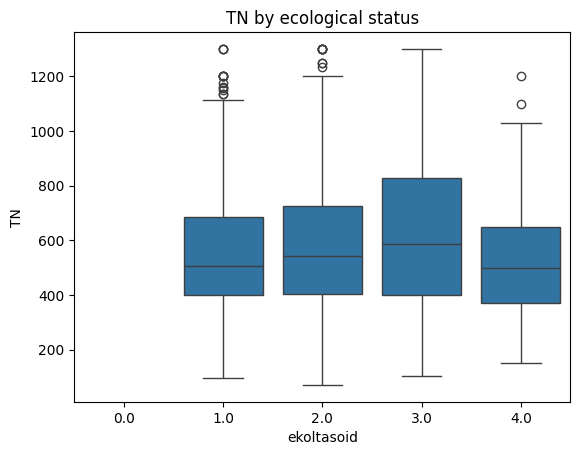

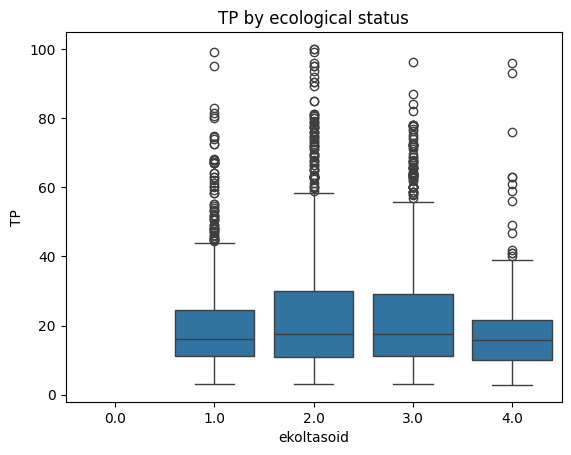

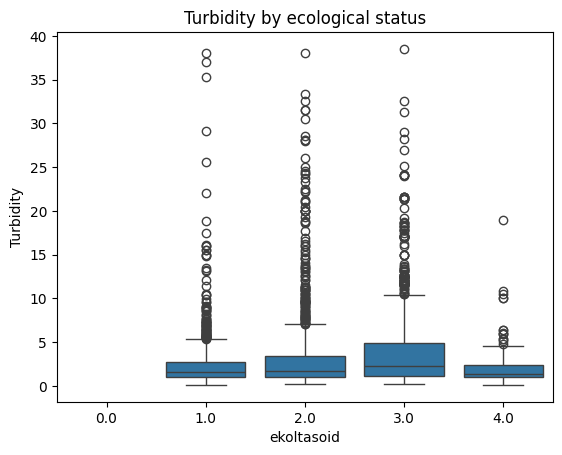

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in ["TN", "TP", "Turbidity"]:
    plt.figure()
    sns.boxplot(x="ekoltasoid", y=var, data=final_df)
    plt.title(f"{var} by ecological status")
    plt.show()

### Intended use

The analysis-ready dataset will be used for machine learning classification of lake ecological status.

### Planned models

- Random Forest
- XGBoost
- Support Vector Machine (SVM)
- Artificial Neural Network (ANN)
- TabNet

### Software

- Python (pandas, scikit-learn, TensorFlow/Keras)

### Target variable

- ekoltasoid (ecological status class)

### Input variables

- TN
- TP
- Turbidity

### Storage structure

- Raw data: ../raw_data/
- Processed data: ../analysis_ready/

### File sizes

The raw datasets are large (hundreds of MB), therefore they are stored outside the repository to ensure efficient version control.

### Reproducibility

All processing steps are scripted in Python and can be reproduced by running the notebook.

### Dependencies

- pandas
- numpy
- seaborn
- matplotlib

Environment is managed using conda.